# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [1]:
from imports import *
from vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [2]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True)

In [3]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,tstep_stopping=True,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:01<00:00, 5971.70it/s]


steps:  10000
conclusion:  0.74
conclusion core 0.74


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.635333,0.568626,0.331201,0.354075,0.771686,0.083042,0.239518,0.195458,0.668037,0.811840,...,0.110113,0.251639,0.830568,0.483223,0.208719,0.342087,0.207402,0.827226,0.330021,0.619007
1,0.626017,0.548905,0.327667,0.352247,0.774493,0.081233,0.240978,0.194203,0.666260,0.814272,...,0.107017,0.251639,0.833919,0.487220,0.212710,0.338496,0.204784,0.826080,0.326493,0.628395
2,0.622263,0.550885,0.327667,0.352247,0.771686,0.074350,0.238064,0.185589,0.666260,0.814272,...,0.109332,0.248638,0.832808,0.469256,0.211374,0.324316,0.206090,0.822605,0.324737,0.620892


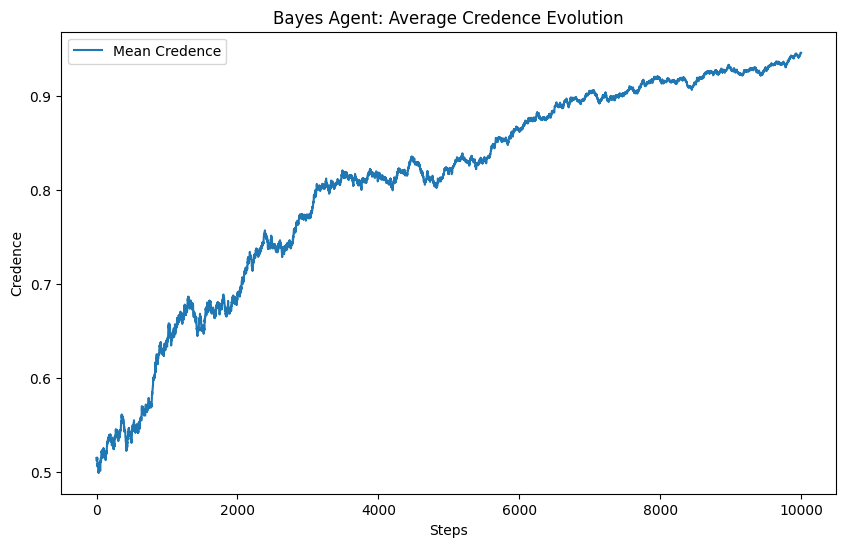

In [4]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [5]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True)

In [6]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,tstep_stopping=True,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:02<00:00, 4539.73it/s]


steps:  10000
conclusion:  0.66


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,"[0.6712498996242945, 0.8824407860287118]","[0.5754455069819191, 0.28831145708464656]","[0.7325767878086519, 0.6775954745961555]","[0.670251939012306, 0.38327090292872246]","[0.828757395440393, 0.14199552023565476]","[0.6577607671894636, 0.3086203866126983]","[0.9994171818267434, 0.2496378832243854]","[0.3914495729864956, 0.17906231722192759]","[0.7084490734441169, 0.6622469856049822]","[0.5541249882418203, 0.49984536812514035]",...,"[0.6025989695855258, 1.0]","[2.3849869109578733e-05, 0.2628996069073922]","[0.008582278712475494, 0.3556488978024374]","[0.08718473396870478, 0.638313207942715]","[0.931255189480539, 0.7894429264195972]","[0.49041544388580816, 0.29319416516901786]","[0.6037847530183496, 0.40807420065697975]","[0.5616248811855957, 0.08006954889161678]","[0.13653687005978132, 0.9999999999568554]","[0.17900067863688973, 0.22686141044125344]"
1,"[0.4818916213919262, 0.7117932799163927]","[0.4962543046837305, 0.49740735298019373]","[0.4529692372621511, 0.4698234535580599]","[0.4049925577314101, 0.5967134220241094]","[0.5049974751806592, 0.3800678367416008]","[0.4010493461069566, 0.4698454762962093]","[0.46638339976159277, 0.5687017817054799]","[0.4974674076541875, 0.590288611857717]","[0.6361775891146118, 0.7808677557656079]","[0.4537297637917321, 0.515849893904814]",...,"[0.6029772313043433, 0.5912513565025026]","[0.5082834484285721, 0.45687251454323197]","[0.4306193244350011, 0.6899669993972145]","[0.5614792521525171, 0.5267303816428685]","[0.4451664648961718, 0.6051629265678234]","[0.5821611979081496, 0.32903471903929743]","[0.5058133137152782, 0.6319793479740793]","[0.4594525167672366, 0.4913173917390391]","[0.4747698022662378, 0.6993213535730978]","[0.39583509312312537, 0.511610886715479]"
2,"[0.5968170161897957, 0.4985377471309358]","[0.5520498432838467, 0.4603422082181807]","[0.4742189607702209, 0.5012356983382245]","[0.4810369458737474, 0.5662289826658949]","[0.4607210464628325, 0.3358086299176528]","[0.43426466678842424, 0.5592574854064299]","[0.444847977659116, 0.516837060007311]","[0.5551303223613245, 0.49345163650035045]","[0.42198922615754, 0.5933297272403648]","[0.47218132587232936, 0.533889201779374]",...,"[0.46373047011640006, 0.5024180045539955]","[0.4598442370110039, 0.5659698233783984]","[0.4602035233084776, 0.5980603769825961]","[0.5423641079719098, 0.4804990158300674]","[0.465616758106753, 0.49491584587964477]","[0.4494695027321976, 0.39054404653056785]","[0.5152222218408226, 0.4811489806078066]","[0.4683557503379255, 0.41979464550069906]","[0.3563666892701384, 0.4283361300621755]","[0.28256030405356825, 0.45859889655017694]"


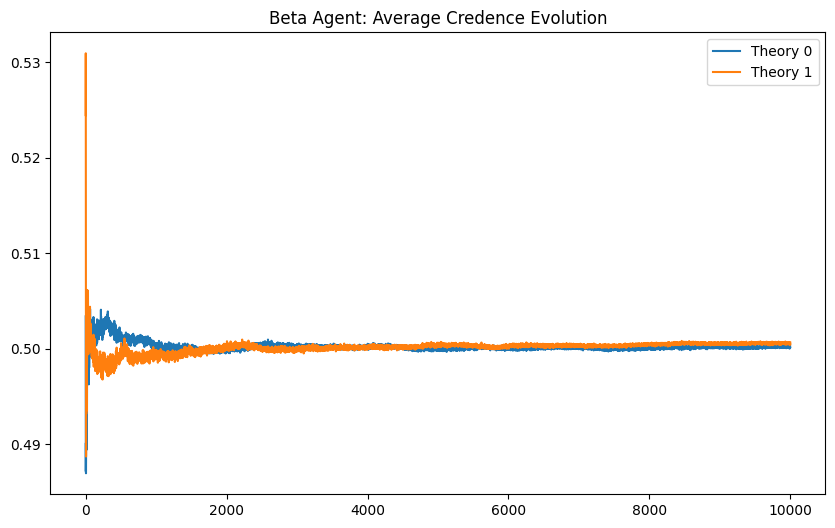

In [7]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

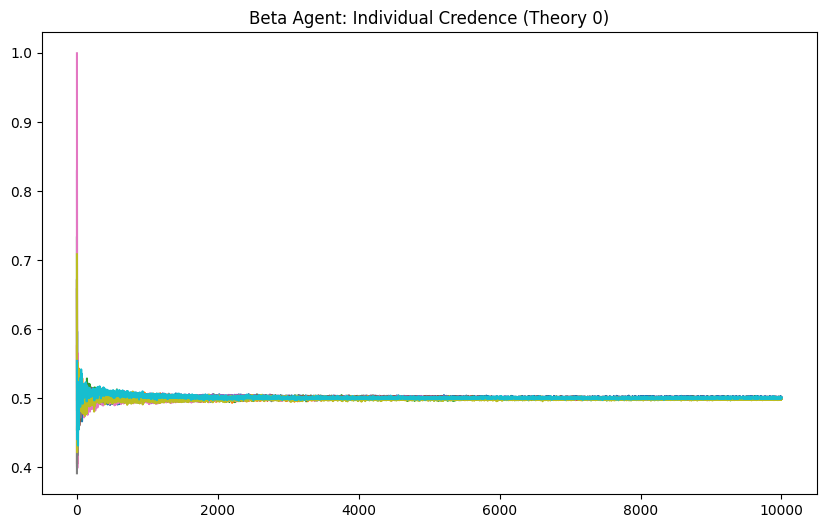

In [8]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()